In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

### QoF

In [2]:
def QoF(y_true, y_pred, model):
        
    #y_true = y_true.numpy().flatten()
    #y_pred = y_pred.numpy().flatten()

    n = len(y_true)
    #p = sum(p.numel() for p in model.parameters() if p.requires_grad)

    residuals = y_true - y_pred
    sse = np.sum(residuals**2)
    sst = np.sum((y_true - np.mean(y_true))**2)

    mse = sse / n
    rmse = np.sqrt(mse)
    mae = np.mean(np.abs(y_true - y_pred))

    r2 = 1 - sse / sst
    
    #aic = n * np.log(sse / n) + 2 * p
    #bic = n * np.log(sse / n) + p * np.log(n)
     
    metrics = {"rSq": r2, 
                "sst": sst,
                "sse": sse,
                "mse": mse,
                "rmse": rmse,
                "mae": mae,
                "m": n
                #"aic": aic,
                #"bic": bic
              }
    
    return metrics

### Plot 

In [3]:
def plot(y_true, y_pred, name):
    
    #y_true = y_true.numpy().flatten()
    #y_pred = y_pred.numpy().flatten()
    
    idx = np.argsort(y_true)
    y_true_sorted = y_true[idx]
    y_pred_sorted = y_pred[idx]

    plt.figure(figsize=(8,5))
    plt.plot(y_pred_sorted, 'r.-', alpha=0.7, label="Predicted")
    plt.plot(y_true_sorted, 'k-', linewidth=2, label="True")
    
    title = name + ": yy black/actual vs. yp red/predicted" 
    plt.xlabel("Index")
    plt.ylabel("Charges")
    plt.title(title)
    plt.legend()

    plt.tight_layout()
    
    plt.savefig(
    "insurance_in_sample_0.05.jpg",        # filename (can be .png, .pdf, .jpg, .svg, etc.)
    dpi=300,           # resolution (higher = better quality)
    bbox_inches='tight',  # removes extra whitespace
    transparent=True   # optional: transparent background
    )

    #plt.show()
    
#plot(y_true, y_pred, "US Health Insurance Dataset NN, In-Sample")

## Load data

In [4]:
df = pd.read_csv("./01.data/new/medical_insurance.csv")
df['alcohol_freq'] = df['alcohol_freq'].replace('NaN', 'Never')
df['alcohol_freq'] = df['alcohol_freq'].fillna('Never')
df['log_medical_cost'] = np.log1p(df['annual_medical_cost'])

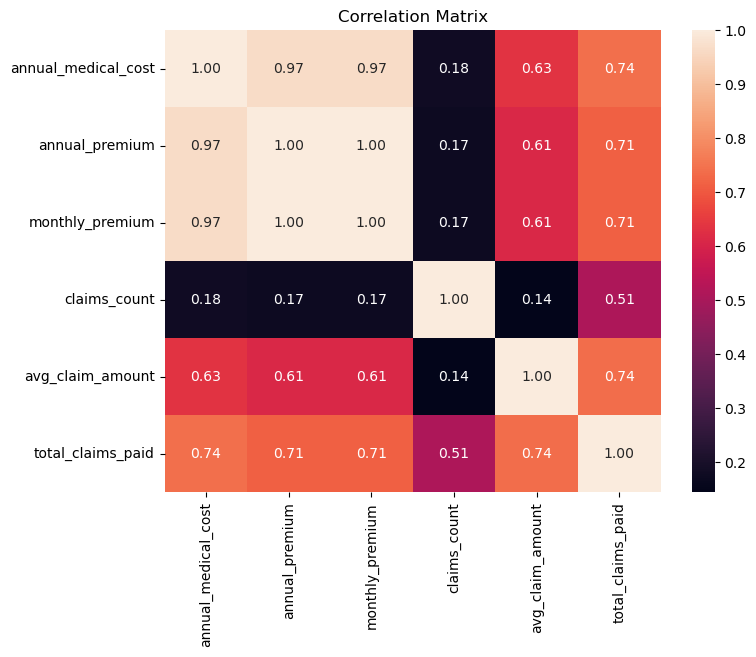

In [5]:
cols = ['annual_medical_cost', 'annual_premium', 'monthly_premium',
        'claims_count', 'avg_claim_amount', 'total_claims_paid']

corr = df[cols].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

In [6]:
X = df.drop(columns=[
    'person_id',
    'annual_medical_cost',
    'log_medical_cost',
    'total_claims_paid',
    'annual_premium',
    'monthly_premium'
])

y = df['annual_medical_cost']

In [7]:
X.columns

Index(['age', 'sex', 'region', 'urban_rural', 'income', 'education',
       'marital_status', 'employment_status', 'household_size', 'dependents',
       'bmi', 'smoker', 'alcohol_freq', 'visits_last_year',
       'hospitalizations_last_3yrs', 'days_hospitalized_last_3yrs',
       'medication_count', 'systolic_bp', 'diastolic_bp', 'ldl', 'hba1c',
       'plan_type', 'network_tier', 'deductible', 'copay', 'policy_term_years',
       'policy_changes_last_2yrs', 'provider_quality', 'risk_score',
       'claims_count', 'avg_claim_amount', 'chronic_count', 'hypertension',
       'diabetes', 'asthma', 'copd', 'cardiovascular_disease',
       'cancer_history', 'kidney_disease', 'liver_disease', 'arthritis',
       'mental_health', 'proc_imaging_count', 'proc_surgery_count',
       'proc_physio_count', 'proc_consult_count', 'proc_lab_count',
       'is_high_risk', 'had_major_procedure'],
      dtype='object')

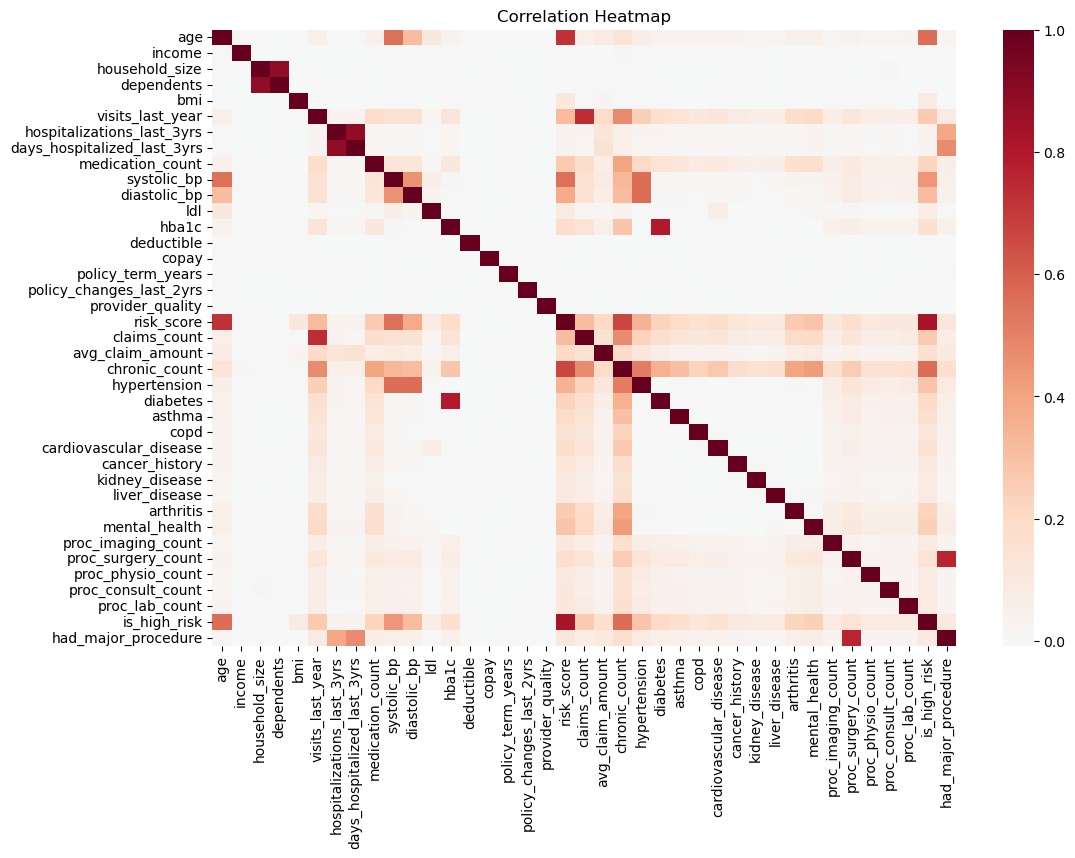

In [8]:
corr = X.corr(numeric_only=True)

plt.figure(figsize=(12,8))
sns.heatmap(corr, annot=False, cmap="RdBu_r", center=0)
plt.title("Correlation Heatmap")
plt.show()

In [9]:
from sklearn.model_selection import train_test_split

X_encoded = pd.get_dummies(X, drop_first=True)

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.8, random_state=42
)

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

rf = RandomForestRegressor(
    n_estimators=300,
    random_state=42
)
rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

rf_mae = mean_absolute_error(y_test, rf_pred)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
rf_r2 = r2_score(y_test, rf_pred)

print("Random Forest:")
print("MAE:", rf_mae)
print("RMSE:", rf_rmse)
print("R2:", rf_r2)

In [ ]:
plot(y_test.values, rf_pred, "US Health Insurance Dataset RF, Out-of-Sample")

In [ ]:
QoF(y_test.values, rf_pred, None)

# Hyperparameter Tuning

In [10]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV


param_dist = {
    'n_estimators': [200, 300, 400, 500, 700],
    'max_depth': [10, 20, 30, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2', 0.5],
    'bootstrap': [True, False]
}

rf_rand = RandomizedSearchCV(
    RandomForestRegressor(random_state=42),
    param_distributions=param_dist,
    n_iter=50,
    scoring='neg_mean_absolute_error',
    cv=5,
    n_jobs=-1,
    random_state=42
)

rf_rand.fit(X_train, y_train)

print("Best params:", rf_rand.best_params_)

/opt/homebrew/Caskroom/miniconda/base/envs/intern/lib/python3.10/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Best params: {'n_estimators': 300, 'min_samples_split': 5, 'min_samples_leaf': 4, 'max_features': 0.5, 'max_depth': None, 'bootstrap': False}


# Tuned Model Performance

In [12]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

best_rf = rf_rand.best_estimator_
best_rf_pred = best_rf.predict(X_test)

print("Tuned RF MAE:", mean_absolute_error(y_test, best_rf_pred))
print("Tuned RF RMSE:", np.sqrt(mean_squared_error(y_test, best_rf_pred)))
print("Tuned RF R2:", r2_score(y_test, best_rf_pred))

Tuned RF MAE: 1000.9367358302885
Tuned RF RMSE: 1799.3470219261164
Tuned RF R2: 0.6652852132329922


# Feature Importance

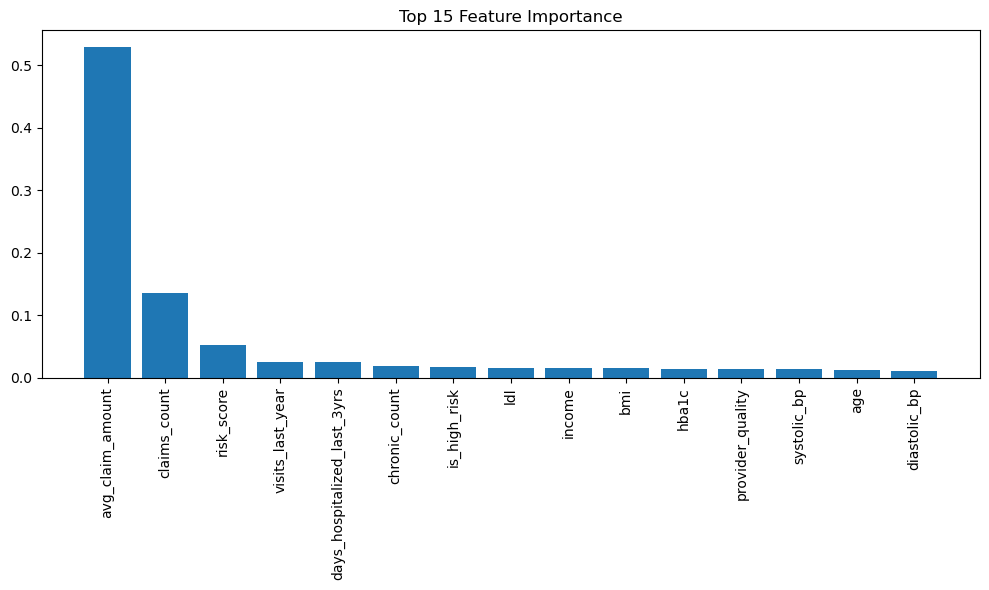

In [13]:
importances = best_rf.feature_importances_
indices = np.argsort(importances)[::-1][:15]

plt.figure(figsize=(10,6))
plt.title("Top 15 Feature Importance")
plt.bar(range(len(indices)), importances[indices])
plt.xticks(range(len(indices)), X_encoded.columns[indices], rotation=90)
plt.tight_layout()
plt.show()

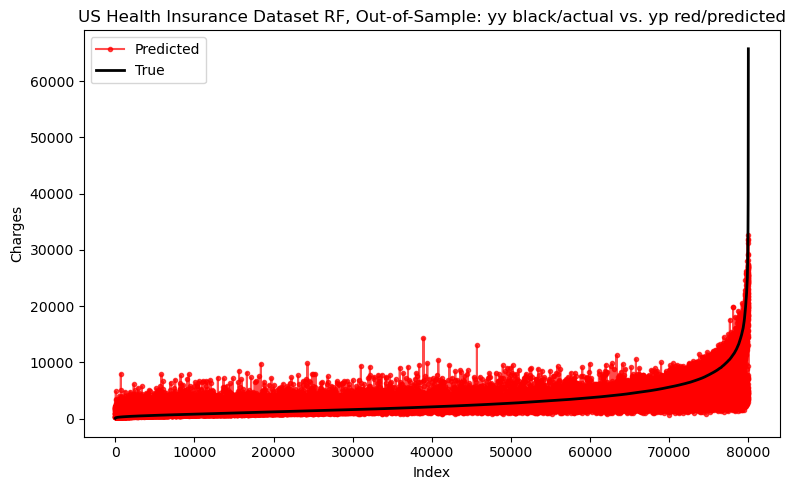

In [15]:
plot(y_test.values, best_rf_pred, "US Health Insurance Dataset RF, Out-of-Sample")

In [16]:
QoF(y_test.values, best_rf_pred, None)

{'rSq': 0.6652852132329922,
 'sst': 773828903488.0519,
 'sse': 259011976425.15076,
 'mse': 3237649.7053143843,
 'rmse': 1799.3470219261164,
 'mae': 1000.9367358302885,
 'm': 80000}